# H3_2 — Árbol de Decisión para Clasificación

**Predicción de acceso a Internet en viviendas de La Paz — Censo 2024**

## 1. Objetivo
Construir y evaluar un árbol de decisión que prediga `TIENE_ACCESO_INTERNET`, y compararlo de forma homogénea con H3_1. El análisis es predictivo y no permite afirmar causalidad.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RAIZ = Path.cwd().resolve()
if RAIZ.name == 'notebooks':
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.decision_tree_classification import (
    MODEL_FEATURES, RANDOM_STATE, TARGET, TARGET_SOURCE, TEST_SIZE,
    crear_pipeline, ejecutar_entrenamiento, resultado_serializable,
)

RUTA_METRICAS = RAIZ / 'outputs/modelado/metricas_arbol_clasificacion.json'
if not RUTA_METRICAS.is_file():
    ejecutar_entrenamiento(RAIZ, prefer_cache=True, save_outputs=True)
resultados = json.loads(RUTA_METRICAS.read_text(encoding='utf-8'))

## 2. Problema de clasificación y variable objetivo
La clase `0` representa viviendas sin acceso y la clase `1` viviendas con acceso. El target deriva exclusivamente de `v19e_f`; el código 9 se excluye y nunca se transforma en clase negativa.

In [2]:
display(pd.Series(resultados['target'], name='Definición del target').to_frame())
display(pd.Series(resultados['distribucion_clases_total'], name='Total').to_frame())

,Definición del target
nombre,TIENE_ACCESO_INTERNET
variable_fuente,v19e_f
descripcion_fuente,Internet fijo en la vivienda o internet móvil
codificacion,"{'0': 'No tiene acceso', '1': 'Tiene acceso'}"
clase_positiva,1
nota_leakage,"v19e_inetfijo, v19f_inetmovil, v19e_f, el targ..."


,Total
0_sin_internet,290940.000000
1_con_internet,748401.000000
porcentaje_clase_positiva,72.007262


## 3. Variables explicativas y prevención de data leakage
Se mantienen exactamente los predictores de H3_1. Las categorías censales se tratan como categorías, no como escalas ordinales. Se excluyen `v19e_inetfijo`, `v19f_inetmovil`, `v19e_f`, el target y cualquier transformación directa del acceso a Internet.

In [3]:
display(pd.DataFrame(resultados['variables_utilizadas']))
print(resultados['target']['nota_leakage'])

,variable,descripcion,tipo,motivo
0,urbrur,Área Urbana - Rural,Categórica,La disponibilidad de infraestructura y cobertu...
1,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),Categórica,El tipo de vivienda aproxima condiciones resid...
2,v09_energia,9. De donde proviene la energía eléctrica que ...,Categórica,La fuente de energía eléctrica representa una ...
3,v19c_compu,"19.3. Su hogar tiene: Computadora, laptop o ta...",Categórica,"La disponibilidad de computadora, laptop o tab..."
4,v19d_celular,19.4. Su hogar tiene: Teléfono celular,Categórica,La tenencia de teléfono celular está asociada ...
5,v13_habitac,"13. Cuántos cuartos o habitaciones ocupan, sin...",Numérica,La cantidad de habitaciones describe el tamaño...
6,tot_pers,Total personas,Numérica,El tamaño del hogar puede relacionarse con la ...


v19e_inetfijo, v19f_inetmovil, v19e_f, el target y sus transformaciones no se usan como predictores.


## 4. Preparación de datos
H3_2 importa la preparación validada en `src.logistic_regression`: mismo universo TIC, limpieza, target e índices. El pipeline imputa la moda en categóricas, aplica one-hot encoding con categorías desconocidas ignoradas e imputa la mediana en numéricas. No se escalan variables.

In [4]:
pipeline_base = crear_pipeline()
pipeline_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",1.0
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded

## 5. División train/test
La partición 80/20 es estratificada, usa `random_state=777` y es la misma de H3_1. Los imputadores y el encoder se ajustan dentro del pipeline, únicamente con train.

In [5]:
display(pd.Series(resultados['particion'], name='Partición').to_frame())
assert all(resultados['verificacion_comparabilidad'].values())

,Partición
test_size,0.2
random_state,777
estratificada,True
train,831472
test,207869
distribucion_train,"{'0_sin_internet': 232752, '1_con_internet': 5..."
distribucion_test,"{'0_sin_internet': 58188, '1_con_internet': 14..."


## 6. Árbol base y optimización mediante GridSearchCV
El estimador base es `DecisionTreeClassifier(random_state=777)`. La búsqueda usa exclusivamente train, cinco folds estratificados y `roc_auc`. Para evitar 3.000 ajustes sobre más de 800 mil registros, se exploran en dos etapas todos los valores solicitados, sin muestrear datos.

In [6]:
grid = resultados['gridsearch']
display(pd.Series(grid['mejores_parametros'], name='Mejor valor').to_frame())
display(pd.DataFrame({
    'mejor_roc_auc_cv': [grid['mejor_roc_auc_cv']],
    'combinaciones': [grid['combinaciones_evaluadas']],
    'ajustes_cv': [grid['ajustes_cv']],
}))
grid_resultados = pd.read_csv(RAIZ / resultados['artefactos']['gridsearch'])
display(grid_resultados.sort_values('rank_test_score').head(10))

,Mejor valor
max_depth,9
min_samples_leaf,5
min_samples_split,2


,mejor_roc_auc_cv,combinaciones,ajustes_cv
0,0.864856,55,275


,etapa,params,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__min_samples_leaf,mean_test_score,std_test_score,rank_test_score,mean_train_score,std_train_score,mean_fit_time,std_fit_time
0,1_profundidad,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,2,1,0.864760,0.001075,1,0.865730,0.000267,56.676994,2.039973
15,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,9,5,0.864856,0.001017,1,0.865691,0.000266,33.739352,2.520512
21,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,3,5,0.864856,0.001017,1,0.865691,0.000266,45.937833,4.790050
20,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,7,5,0.864856,0.001017,1,0.865691,0.000266,45.074431,4.315191
19,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,6,5,0.864856,0.001017,1,0.865691,0.000266,44.597041,3.260651
18,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,4,5,0.864856,0.001017,1,0.865691,0.000266,44.118686,3.172137
17,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,5,5,0.864856,0.001017,1,0.865691,0.000266,41.371557,1.812126
16,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,8,5,0.864856,0.001017,1,0.865691,0.000266,41.326139,1.579879
22,2_regularizacion,"{""modelo__max_depth"": 9, ""modelo__min_samples_...",9,2,5,0.864856,0.001017,1,0.865691,0.000266,47.658673,5.713879
1,1_profundidad,"{""modelo__max_depth"": 10, ""modelo__min_samples...",10,2,1,0.864738,0.001041,2,0.866122,0.000282,58.023416,3.179186


## 7. Evaluación del modelo
Accuracy, precision, recall, F1 y ROC-AUC se calculan en train y test. ROC-AUC utiliza `predict_proba(... )[:, 1]`, no las clases predichas.

In [7]:
metricas = pd.DataFrame(resultados['metricas']).T
display(metricas.style.format('{:.4f}'))
display(pd.DataFrame(resultados['matriz_confusion_test']['matriz'],
    index=['Real: sin Internet', 'Real: con Internet'],
    columns=['Predicho: sin Internet', 'Predicho: con Internet']))

,accuracy,precision,recall,f1,roc_auc
train,0.8055,0.8232,0.9295,0.8731,0.8656
test,0.8054,0.8237,0.9285,0.8730,0.8652


,Predicho: sin Internet,Predicho: con Internet
Real: sin Internet,28439,29749
Real: con Internet,10700,138981


## 8. Curva ROC

In [8]:
roc = pd.DataFrame(resultados['roc']['puntos'])
ax = roc.plot(x='fpr', y='tpr', figsize=(7, 6), lw=2, label=f"Árbol (AUC={resultados['roc']['auc_test']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='gray', label='Azar')
ax.set(xlabel='Tasa de falsos positivos', ylabel='Tasa de verdaderos positivos', title='Curva ROC — test')
ax.legend(); plt.show()

/tmp/ipykernel_26010/4257577721.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(); plt.show()


## 9. Selección de umbral
El umbral ROC maximiza el índice de Youden usando probabilidades out-of-fold de train. No se mira test para seleccionarlo y no sustituye silenciosamente el umbral estándar 0,5.

In [9]:
umbral = resultados['seleccion_umbral_roc']
display(pd.DataFrame({
    'umbral 0,5': resultados['metricas']['test'],
    f"umbral ROC {umbral['umbral']:.3f}": umbral['metricas_test'],
}).T.style.format('{:.4f}'))
print(umbral['criterio'])
print(umbral['origen'])

,accuracy,precision,recall,f1,roc_auc
"umbral 0,5",0.8054,0.8237,0.9285,0.8730,0.8652
umbral ROC 0.740,0.7430,0.9243,0.7004,0.7969,0.8652


Máximo índice de Youden (TPR - FPR) sobre probabilidades out-of-fold de train
train, validación cruzada estratificada de 5 folds


## 10. Importancia de variables
Se presentan tanto las features transformadas como la suma por variable original. La vista agregada facilita interpretar el efecto total de las categorías one-hot.

In [10]:
imp_agregada = pd.read_csv(RAIZ / resultados['artefactos']['importancia_agregada'])
imp_transformada = pd.read_csv(RAIZ / resultados['artefactos']['importancia_transformada'])
display(imp_agregada.style.format({'importancia': '{:.4f}'}))
display(imp_transformada.head(15).style.format({'importancia': '{:.4f}'}))
imp_agregada.sort_values('importancia').plot.barh(x='variable_original', y='importancia', legend=False, figsize=(8, 5), color='#b26128');
plt.xlabel('Importancia'); plt.ylabel('Variable original'); plt.show()

,variable_original,importancia
0,v19d_celular,0.5553
1,v19c_compu,0.2938
2,urbrur,0.1017
3,tot_pers,0.0347
4,v09_energia,0.0073
5,v01_tipoviv,0.0054
6,v13_habitac,0.0018


,feature,variable_original,categoria_codigo,categoria,importancia
0,v19d_celular_2,v19d_celular,2.000000,No,0.5553
1,v19c_compu_2,v19c_compu,2.000000,No,0.2938
2,urbrur_1,urbrur,1.000000,Urbana,0.1017
3,tot_pers,tot_pers,nan,nan,0.0347
4,v09_energia_5,v09_energia,5.000000,No tiene,0.0042
5,v09_energia_1,v09_energia,1.000000,Servicio público de energía eléctrica,0.0024
6,v01_tipoviv_3,v01_tipoviv,3.000000,Departamento,0.0021
7,v01_tipoviv_1,v01_tipoviv,1.000000,Casa,0.0020
8,v13_habitac,v13_habitac,nan,nan,0.0018
9,v01_tipoviv_4,v01_tipoviv,4.000000,Cuarto(s) o habitación(es) suelta(s),0.0006


/tmp/ipykernel_26010/4234154483.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.xlabel('Importancia'); plt.ylabel('Variable original'); plt.show()


## 11. Visualización parcial del árbol
La figura limita la presentación a los niveles 0–3. La estructura y el archivo `.joblib` conservan el árbol completo.

,Estructura
profundidad,9
nodos,665
hojas,333
visualizacion_max_depth,3
nota_visualizacion,La figura muestra solo los niveles 0 a 3; el m...


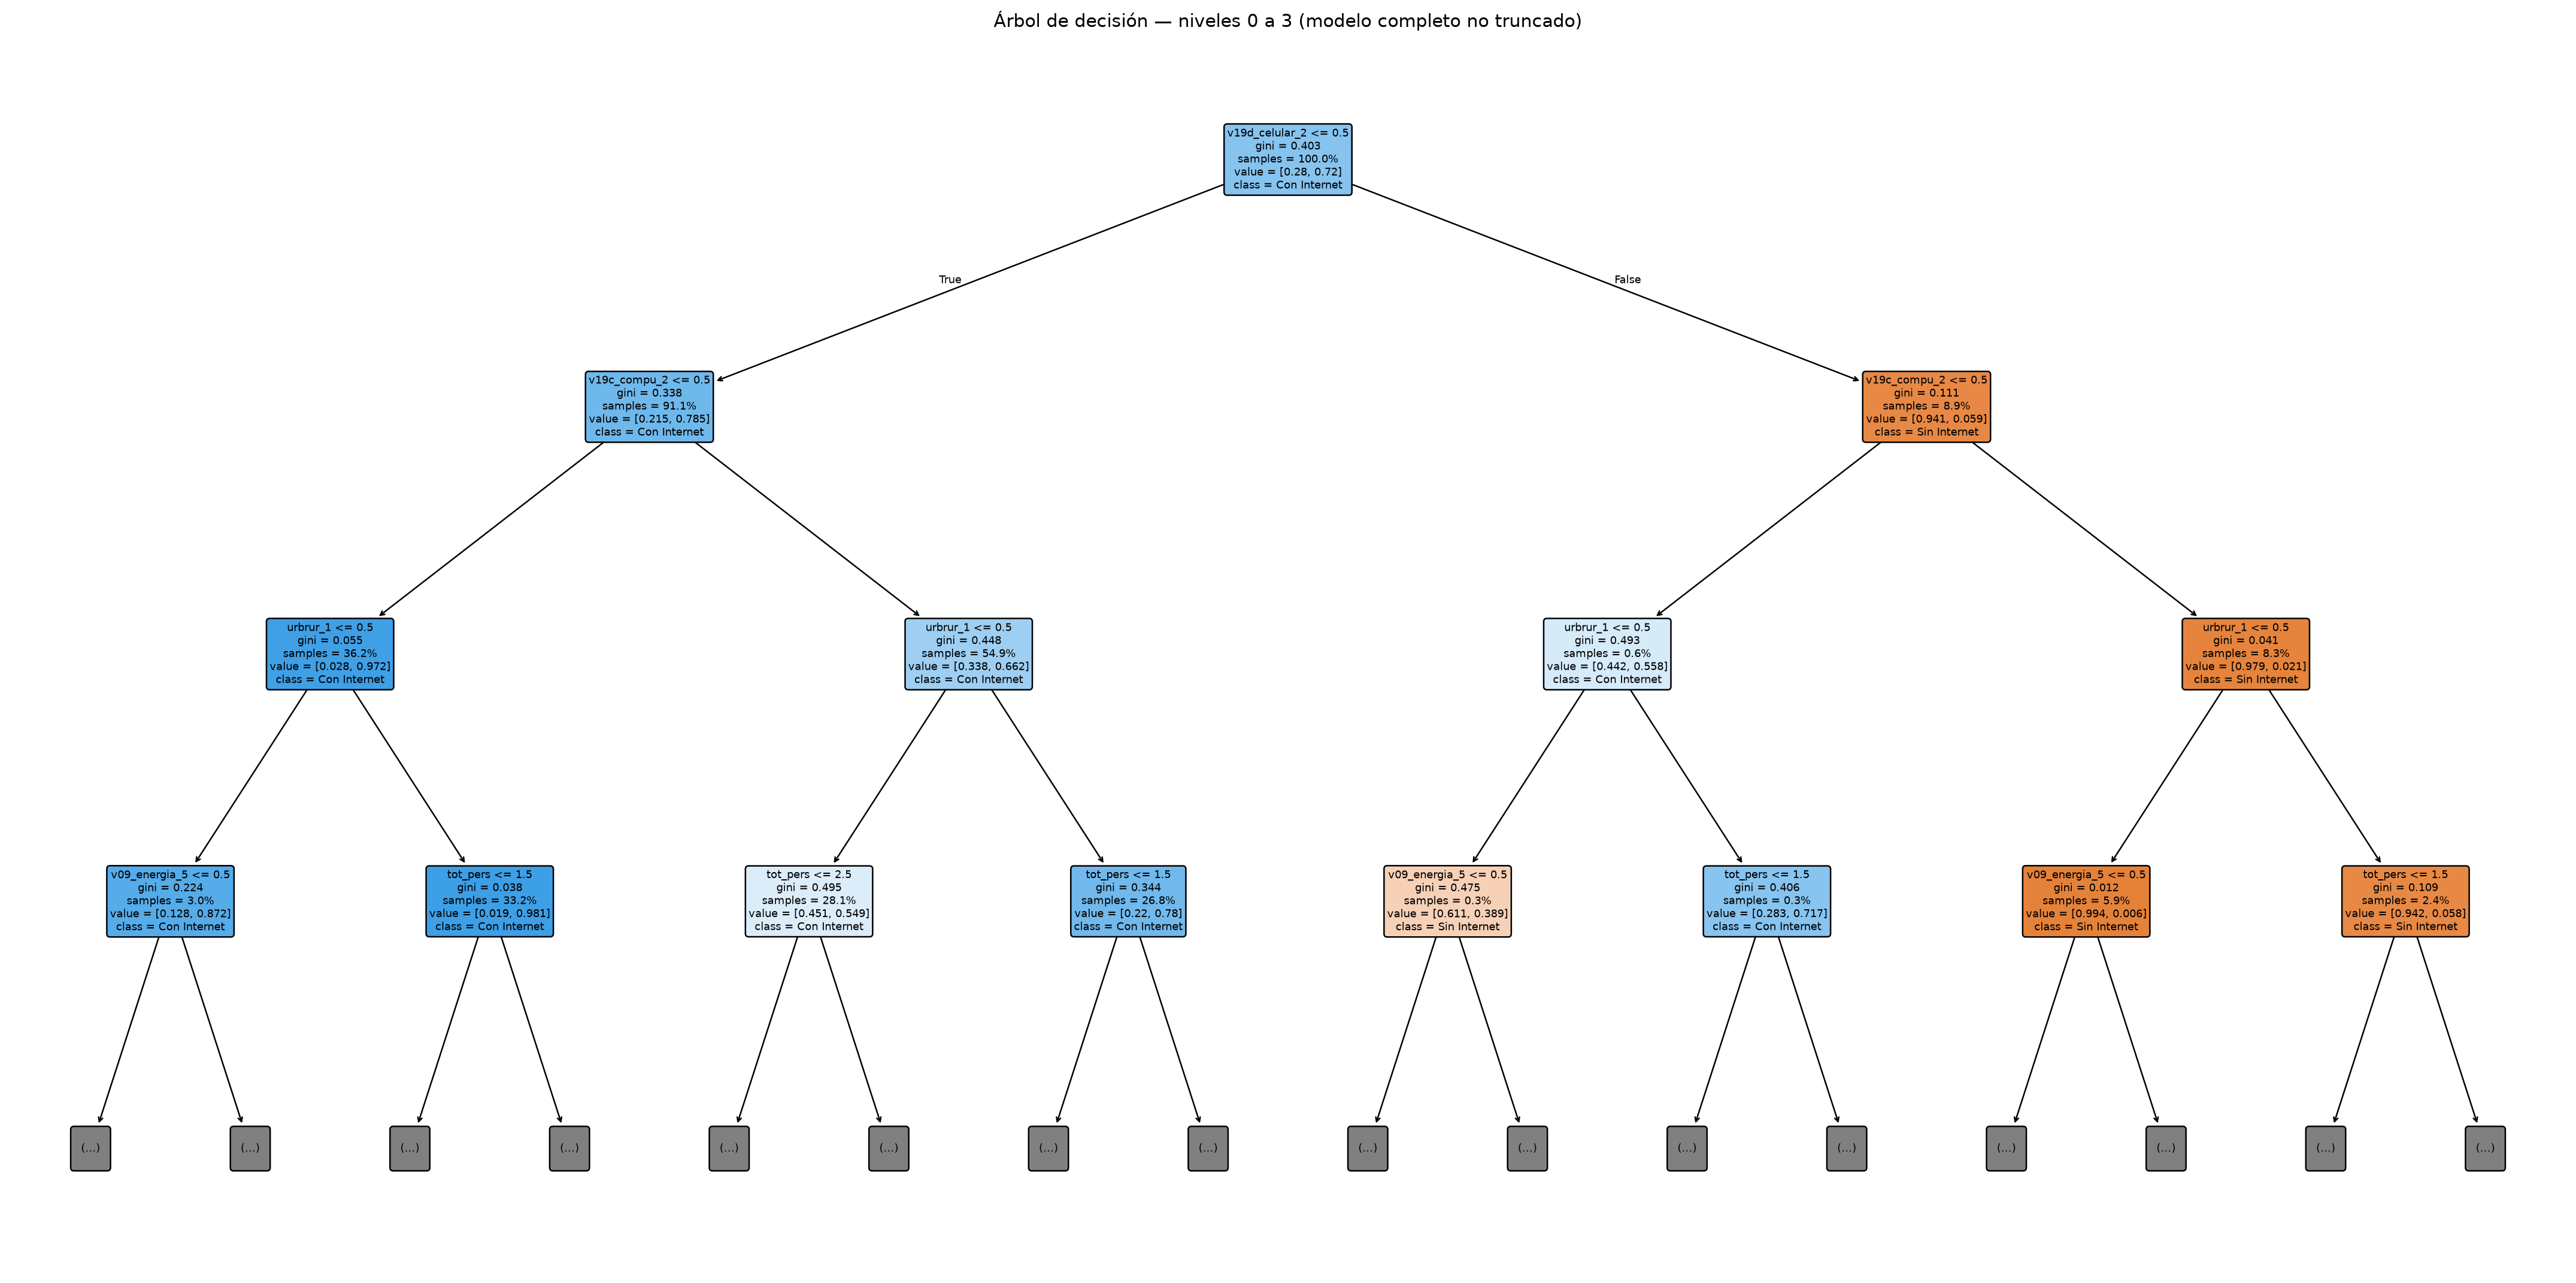

In [11]:
display(pd.Series(resultados['estructura_arbol'], name='Estructura').to_frame())
display(Image(filename=str(RAIZ / resultados['artefactos']['grafico_arbol'])))

## 12. Comparación con Regresión Logística
Ambos modelos usan el mismo universo, target, variables, `random_state`, estratificación e índices de test. No se declara automáticamente un ganador.

In [12]:
comparacion = pd.DataFrame(resultados['comparacion_modelos']).set_index('modelo')
display(comparacion.style.format('{:.4f}'))
comparacion.T.plot.bar(figsize=(10, 5), ylim=(0, 1), color=['#167f87', '#b26128'])
plt.ylabel('Valor'); plt.title('Comparación de modelos de clasificación — test'); plt.xticks(rotation=0); plt.show()

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresión Logística,0.8034,0.8144,0.9416,0.8734,0.8625
Árbol de Decisión,0.8054,0.8237,0.9285,0.8730,0.8652


/tmp/ipykernel_26010/1616889074.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.ylabel('Valor'); plt.title('Comparación de modelos de clasificación — test'); plt.xticks(rotation=0); plt.show()


## 13. Interpretación, conclusiones y limitaciones

In [13]:
print(resultados['interpretacion'])
mejor_variable = imp_agregada.iloc[0]
print(f"La mayor importancia agregada corresponde a {mejor_variable['variable_original']} ({mejor_variable['importancia']:.3f}).")
print('La importancia no implica causalidad. Los resultados dependen de los predictores disponibles, la calidad censal y la población definida por el universo TIC.')

Las métricas de train y test son cercanas; no aparece una brecha importante de generalización. El resultado describe asociaciones predictivas y no efectos causales.
La mayor importancia agregada corresponde a v19d_celular (0.555).
La importancia no implica causalidad. Los resultados dependen de los predictores disponibles, la calidad censal y la población definida por el universo TIC.
